In [23]:
from sentiment_classifier.utils.utils import get_root_dir
from sentiment_classifier.data.retrieval import read_csv
from sentiment_classifier.data.retrieval import get_train_test_data
from sentiment_classifier.utils.utils import read_config
import spacy
import scattertext
import seaborn as sns

c:\Users\manue\Documents\NLP_usecases\sentiment_classifier\.venv\Lib\site-packages\scattertext\dispersion\offset_inter_arrivals.py:126: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if last_token_count is 0: last_token_count = 1
c:\Users\manue\Documents\NLP_usecases\sentiment_classifier\.venv\Lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [22]:
nlp = spacy.load('en_core_web_lg')

c:\Users\manue\Documents\NLP_usecases\sentiment_classifier\.venv\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
c:\Users\manue\Documents\NLP_usecases\sentiment_classifier\.venv\Lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [12]:
configs = read_config("data_config")
root = get_root_dir()
data_path = root / configs["source_data"]
df = read_csv(
    data_path, encoding="latin-1", header=None, names=["sentiment", "text"]
)

train, test = get_train_test_data(df)

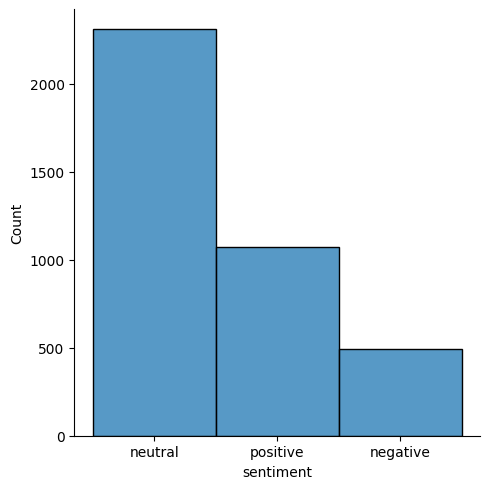

In [20]:
sns.displot(train["sentiment"])

In [32]:
def term_freq(df_yelp):
    corpus = (scattertext.CorpusFromPandas(df_yelp,
                                           category_col='sentiment', 
                                           text_col='text',
                                           nlp=nlp)
              .build()
              .remove_terms(nlp.Defaults.stop_words, ignore_absences=True)
              )
    df = corpus.get_term_freq_df()
    df['positive_score'] = corpus.get_scaled_f_scores('positive')
    df['negative_score'] = corpus.get_scaled_f_scores('negative')
    df['neutral_score'] = corpus.get_scaled_f_scores('neutral')

    df['positive_score'] = round(df['positive_score'], 2)
    df['negative_score'] = round(df['negative_score'], 2)
    df['neutral_score'] = round(df['neutral_score'], 2)
    
    df_positive = df.sort_values(by='Positive freq', 
                             ascending = False).reset_index()
    df_negative = df.sort_values(by='Negative freq', 
                            ascending=False).reset_index()
    df_neutral = df.sort_values(by='Neutral freq', 
                            ascending=False).reset_index()
    
    return df_positive, df_negative, df_neutral

In [33]:
df = term_freq(train)

In [34]:
df

,neutral freq,positive freq,negative freq,positive_score,negative_score,neutral_sore
term,,,,,,
russia,38,26,3,0.884454,0.027670,0.136414
raisio,8,6,1,0.820866,0.106288,0.241741
food,23,13,2,0.862626,0.033085,0.861202
division,16,10,3,0.857467,0.074090,0.149274
home,9,4,3,0.153621,0.732036,0.788184
...,...,...,...,...,...,...
7.4 m,0,1,0,0.550776,0.500000,0.465158
m extension,0,1,0,0.550776,0.500000,0.465158
existing consultancy,0,1,0,0.550776,0.500000,0.465158


In [30]:
df_positive, df_negative, df_neutral = term_freq(train)

KeyError: 'positive'

In [31]:
train["sentiment"]

432      neutral
3071     neutral
289     positive
2588     neutral
4121     neutral
          ...   
4426    negative
466     positive
3092     neutral
3772     neutral
860     positive
Name: sentiment, Length: 3876, dtype: object